<a href="https://www.kaggle.com/code/arwabasal/dicom-hippocampal?scriptVersionId=317916008" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Current code checks:

Are there valid images? (not corrupted)

Are slices in correct anatomical order?

What's the image shape? (256x256? 512x512?)

Are there blank/damaged slices?

Can we stack them into a 3D volume?

 ### TL;DR it's preprocessing :)

In [1]:
import pydicom
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path


def is_valid_image_dicom(ds):
    """
    Check if DICOM contains actual image pixel data
    """
    # Check for pixel data attribute
    if not hasattr(ds, 'pixel_array'):
        return False
    
    # Try to access pixel_array - if it fails, it's not an image
    try:
        _ = ds.pixel_array
        return True
    except:
        return False

def get_slice_number(ds):
    """
    Try multiple DICOM tags to determine slice order
    """
    if hasattr(ds, 'InstanceNumber'):
        return int(ds.InstanceNumber)
    elif hasattr(ds, 'SliceLocation'):
        return float(ds.SliceLocation)
    elif hasattr(ds, 'ImagePositionPatient'):
        return float(ds.ImagePositionPatient[2])
    elif hasattr(ds, 'AcquisitionNumber'):
        return int(ds.AcquisitionNumber)
    else:
        return 0

def load_valid_dicoms_from_folder(folder_path):
    """
    Load ONLY DICOM files that contain actual image data
    """
    dicom_list = []
    skipped_files = []
    
    # Get all files in the folder
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.dcm'):
            file_path = os.path.join(folder_path, file_name)
            try:
                ds = pydicom.dcmread(file_path)
                
                
                if is_valid_image_dicom(ds):
                    dicom_list.append(ds)
                    print(f"Loaded image: {file_name}")
                else:
                    skipped_files.append(file_name)
                    print(f"Skipped (no pixel data): {file_name}")
                    
            except Exception as e:
                skipped_files.append(file_name)
                print(f"Error with {file_name}: {e}")
    
    if skipped_files:
        print(f"\nSkipped {len(skipped_files)} non-image files")
    
    return dicom_list

Loaded image: MR.1.2.246.352.221.55685483938290936304826787115937244607.dcm
Loaded image: MR.1.2.246.352.221.46620217304493734562111362943041802116.dcm
Loaded image: MR.1.2.246.352.221.46610297499567687196592583109429057944.dcm
Loaded image: MR.1.2.246.352.221.551312179015625932810521172476992959900.dcm
Loaded image: MR.1.2.246.352.221.55732483383214337663879853476263275668.dcm
Loaded image: MR.1.2.246.352.221.50461636963045286912170585618040083391.dcm
Loaded image: MR.1.2.246.352.221.564450496057936124114845395802853573002.dcm
Loaded image: MR.1.2.246.352.221.533451626049161440516273437078279751823.dcm
Loaded image: MR.1.2.246.352.221.500172538559138195812802166284930379926.dcm
Loaded image: MR.1.2.246.352.221.53072650337294152187781030760782669745.dcm
Loaded image: MR.1.2.246.352.221.54384399864872628901983572494868075959.dcm
Loaded image: MR.1.2.246.352.221.53388550903220954562054978119859336580.dcm
Loaded image: MR.1.2.246.352.221.513057741987312887518398267393569754779.dcm
Loaded 

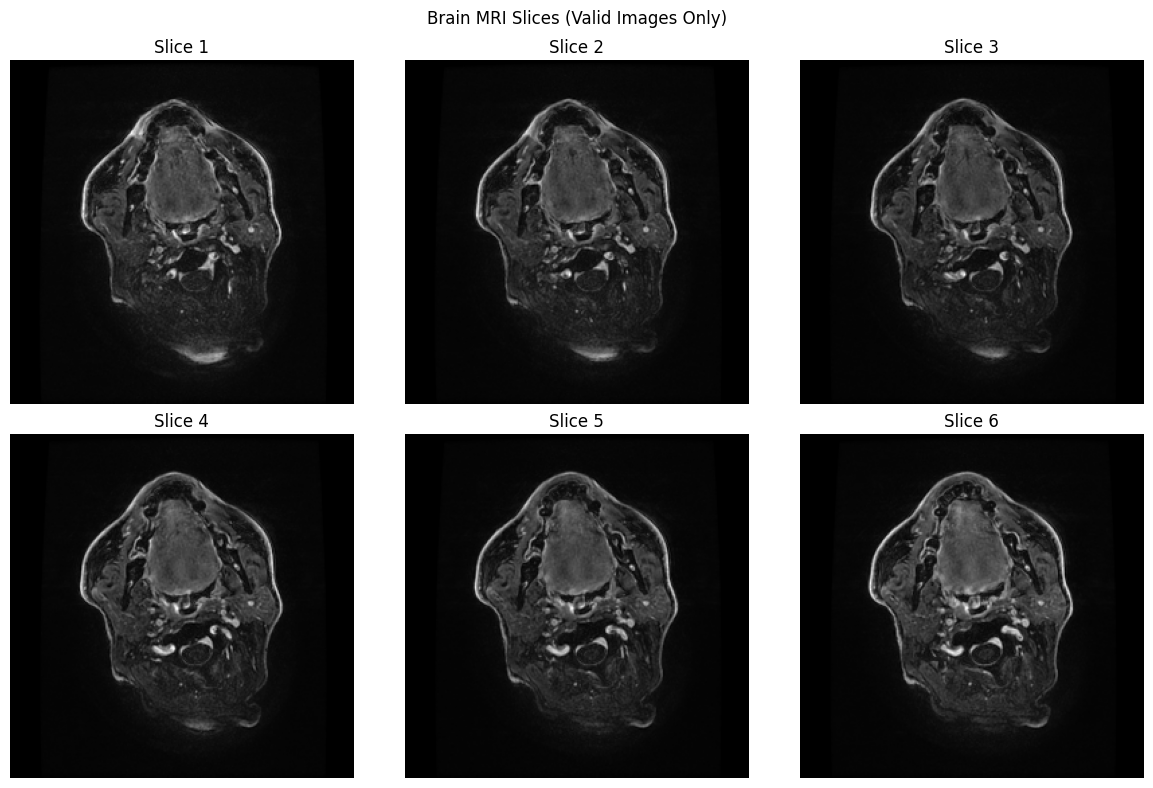

In [2]:
folder_path = "/kaggle/input/datasets/aryashah2k/hippocampal-sparing-dataset/HippocampalMRISlices/01"


dicom_datasets = load_valid_dicoms_from_folder(folder_path)
print(f"\n Total valid image DICOMs loaded: {len(dicom_datasets)}")

# Check if we have any images
if len(dicom_datasets) == 0:
    print("No valid DICOM images found! Let's investigate the folder structure...")
    
    # Investigate what's actually in the folder
    print(f"\n Contents of {folder_path}:")
    for file_name in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file_name)
        file_size = os.path.getsize(file_path) / 1024  # KB
        print(f"   - {file_name} ({file_size:.1f} KB)")
    
    # Try reading first file to see what's wrong
    first_file = [f for f in os.listdir(folder_path) if f.endswith('.dcm')][0]
    test_ds = pydicom.dcmread(os.path.join(folder_path, first_file))
    print(f"\n First DICOM metadata:")
    print(f"   Modality: {test_ds.get('Modality', 'Not found')}")
    print(f"   SOP Class UID: {test_ds.get('SOPClassUID', 'Not found')}")
    print(f"   Has pixel_array: {hasattr(test_ds, 'pixel_array')}")
    
    # List all attributes
    print(f"\n   Available attributes: {[attr for attr in dir(test_ds) if not attr.startswith('_')][:20]}")
    
else:
  
    
    # Sort using the smart function
    dicom_datasets.sort(key=get_slice_number)
    print(f"\n Sorted {len(dicom_datasets)} image slices successfully!")
    
    # Display slice order information
    print(f"\n Slice order info (first 5 slices):")
    for i in range(min(5, len(dicom_datasets))):
        ds = dicom_datasets[i]
        slice_id = get_slice_number(ds)
        modality = ds.get('Modality', 'Unknown')
        print(f"   Slice {i}: sorting value = {slice_id}, Modality = {modality}")

    
    # Display first 6 slices in a grid
    num_slices_to_show = min(6, len(dicom_datasets))
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.ravel()
    
    for i in range(num_slices_to_show):
        ds = dicom_datasets[i]
        image = ds.pixel_array
        
        # Normalize for display
        image_normalized = (image - image.min()) / (image.max() - image.min())
        
        axes[i].imshow(image_normalized, cmap='gray')
        
        # Try to get slice number safely
        try:
            slice_num = ds.InstanceNumber if hasattr(ds, 'InstanceNumber') else i+1
            axes[i].set_title(f"Slice {slice_num}")
        except:
            axes[i].set_title(f"Slice {i+1}")
        
        axes[i].axis('off')
    
    plt.suptitle(f"Brain MRI Slices (Valid Images Only)")
    plt.tight_layout()
    plt.show()

 Creating volume: 276 slices of size 256x256

 3D Volume Shape: (276, 256, 256)
   (Slices x Height x Width)
   Memory usage: 69.00 MB

 Exploring folder structure:
   - HippocampalMRISlices (7733 DICOM files)
   No mask files found in this dataset structure
   This dataset may have masks stored separately or only in specific patient folders

 Volume Statistics:
   Min intensity: 0.00
   Max intensity: 14838.00
   Mean intensity: 912.68
   Std deviation: 1456.23

 No blank slices detected - good quality volume!

 Saved 3D volume to: hippocampus_patient_01_volume.npy
   Loading code: volume = np.load('hippocampus_patient_01_volume.npy')
 Saved metadata to: volume_metadata.json


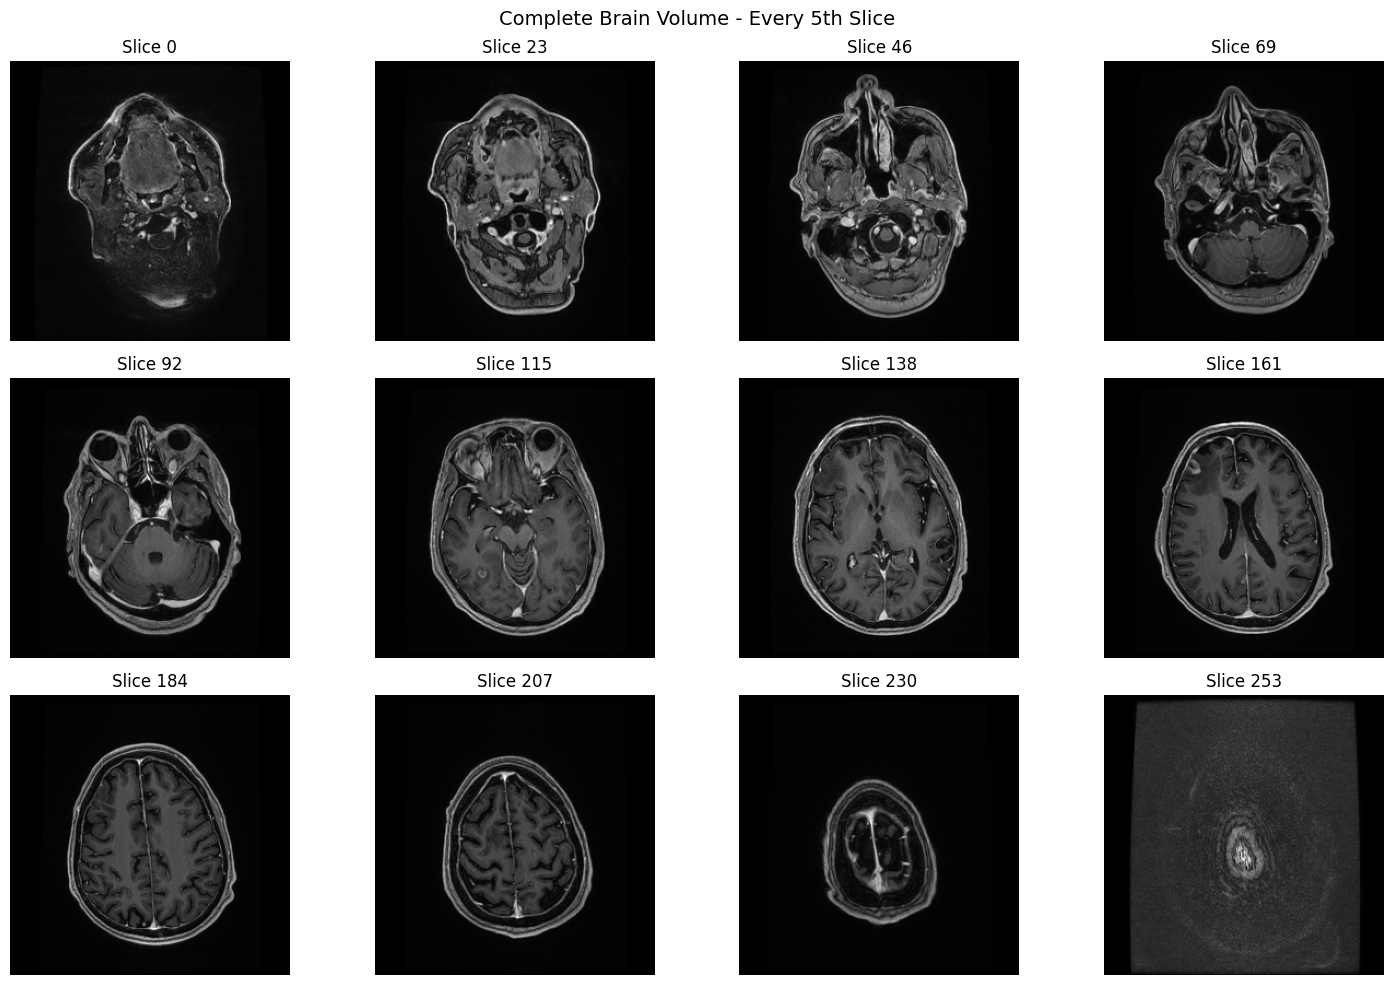

In [3]:
    
    def create_3d_volume(dicom_datasets):
        """
        Stack all 2D slices into a single 3D numpy array
        """
        # Get dimensions from first slice
        first_slice = dicom_datasets[0]
        height, width = first_slice.pixel_array.shape
        num_slices = len(dicom_datasets)
        
        print(f" Creating volume: {num_slices} slices of size {height}x{width}")
        
        # Create empty 3D array (Depth, Height, Width)
        volume = np.zeros((num_slices, height, width), dtype=np.float32)
        
        for i, ds in enumerate(dicom_datasets):
            volume[i, :, :] = ds.pixel_array.astype(np.float32)
        
        return volume
    
    # Create the 3D volume
    mri_volume = create_3d_volume(dicom_datasets)
    print(f"\n 3D Volume Shape: {mri_volume.shape}")
    print(f"   (Slices x Height x Width)")
    print(f"   Memory usage: {mri_volume.nbytes / 1024 / 1024:.2f} MB")
    

    
    # Check if this dataset has segmentation masks
    base_path = Path("/kaggle/input/datasets/aryashah2k/hippocampal-sparing-dataset")
    print(f"\n Exploring folder structure:")
    for subfolder in base_path.iterdir():
        if subfolder.is_dir():
            # Count files in subfolder
            try:
                num_files = len(list(subfolder.rglob("*.dcm")))
                print(f"   - {subfolder.name} ({num_files} DICOM files)")
            except:
                print(f"   - {subfolder.name}")
    
    # Look for masks in all possible locations
    mask_found = False
    for item in base_path.rglob("*"):
        if item.is_file():
            item_lower = str(item).lower()
            if any(keyword in item_lower for keyword in ['mask', 'seg', 'label', 'roi']):
                print(f"   Found potential mask: {item.name}")
                mask_found = True
    
    if not mask_found:
        print(f"   No mask files found in this dataset structure")
        print(f"   This dataset may have masks stored separately or only in specific patient folders")
    

    
    # Basic statistics
    print(f"\n Volume Statistics:")
    print(f"   Min intensity: {mri_volume.min():.2f}")
    print(f"   Max intensity: {mri_volume.max():.2f}")
    print(f"   Mean intensity: {mri_volume.mean():.2f}")
    print(f"   Std deviation: {mri_volume.std():.2f}")
    
    # Check for blank slices
    blank_threshold = 10
    blank_slices = []
    for i in range(mri_volume.shape[0]):
        if mri_volume[i].max() - mri_volume[i].min() < blank_threshold:
            blank_slices.append(i)
    
    if blank_slices:
        print(f"\n  Found {len(blank_slices)} blank/low-contrast slices at positions: {blank_slices[:5]}")
    else:
        print(f"\n No blank slices detected - good quality volume!")
    

    
    # Save the 3D volume
    output_file = 'hippocampus_patient_01_volume.npy'
    np.save(output_file, mri_volume)
    print(f"\n Saved 3D volume to: {output_file}")
    print(f"   Loading code: volume = np.load('{output_file}')")
    
    # Save metadata dictionary
    metadata = {
        'num_slices': len(dicom_datasets),
        'slice_shape': dicom_datasets[0].pixel_array.shape,
        'modality': dicom_datasets[0].get('Modality', 'Unknown'),
        'patient_name': str(dicom_datasets[0].get('PatientName', 'Unknown')),
        'slice_positions': [get_slice_number(ds) for ds in dicom_datasets]
    }
    
    import json
    with open('volume_metadata.json', 'w') as f:
        json.dump(metadata, f, indent=2)
    print(f" Saved metadata to: volume_metadata.json")
    

    
    # Create a montage of every 5th slice
    step = max(1, len(dicom_datasets) // 12)
    montage_slices = range(0, len(dicom_datasets), step)
    montage_images = [dicom_datasets[i].pixel_array for i in montage_slices]
    
    fig, axes = plt.subplots(3, 4, figsize=(15, 10))
    axes = axes.ravel()
    
    for idx, img in enumerate(montage_images[:12]):
        img_norm = (img - img.min()) / (img.max() - img.min())
        axes[idx].imshow(img_norm, cmap='gray')
        axes[idx].set_title(f"Slice {idx*step}")
        axes[idx].axis('off')
    
    plt.suptitle("Complete Brain Volume - Every 5th Slice", fontsize=14)
    plt.tight_layout()
    plt.show()